# Student Depression Prediction — SVM Classifier

**Target:** `Depression` (True / False → 1 / 0)
**Dataset:** `student_lifestyle_100k.csv` (100,000 rows)

### SVM Strategy for 100k rows
Standard `SVC(kernel='rbf')` times out on datasets this large (kernel matrix is O(n²)).
The correct sklearn approach for large datasets is:
- **Primary model:** `LinearSVC` + `CalibratedClassifierCV` — scales linearly, full dataset
- **RBF demo:** `SVC(kernel='rbf')` trained on a 5k stratified sample for kernel comparison

### Dataset limitations
- **90/10 class imbalance** — only 10% are depressed
- **Max feature correlation with Depression = 0.18** (CGPA)
- These are data limitations, not model failures

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    average_precision_score, PrecisionRecallDisplay
)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
TARGET       = 'Depression'
CLASS_LABELS = ['Not Depressed', 'Depressed']
print('All imports successful')

All imports successful


## 2. Load Dataset

In [2]:
DATA_PATH = 'student_lifestyle_100k.csv'

df = pd.read_csv(DATA_PATH)
df['Depression'] = df['Depression'].astype(int)
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 11)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,0
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,0
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,0
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,0
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,0


## 3. EDA

In [3]:
counts = df[TARGET].value_counts().sort_index()
for idx, cnt in counts.items():
    print(f'{CLASS_LABELS[idx]}: {cnt:,} ({100*cnt/len(df):.1f}%)')

Not Depressed: 89,938 (89.9%)
Depressed: 10,062 (10.1%)


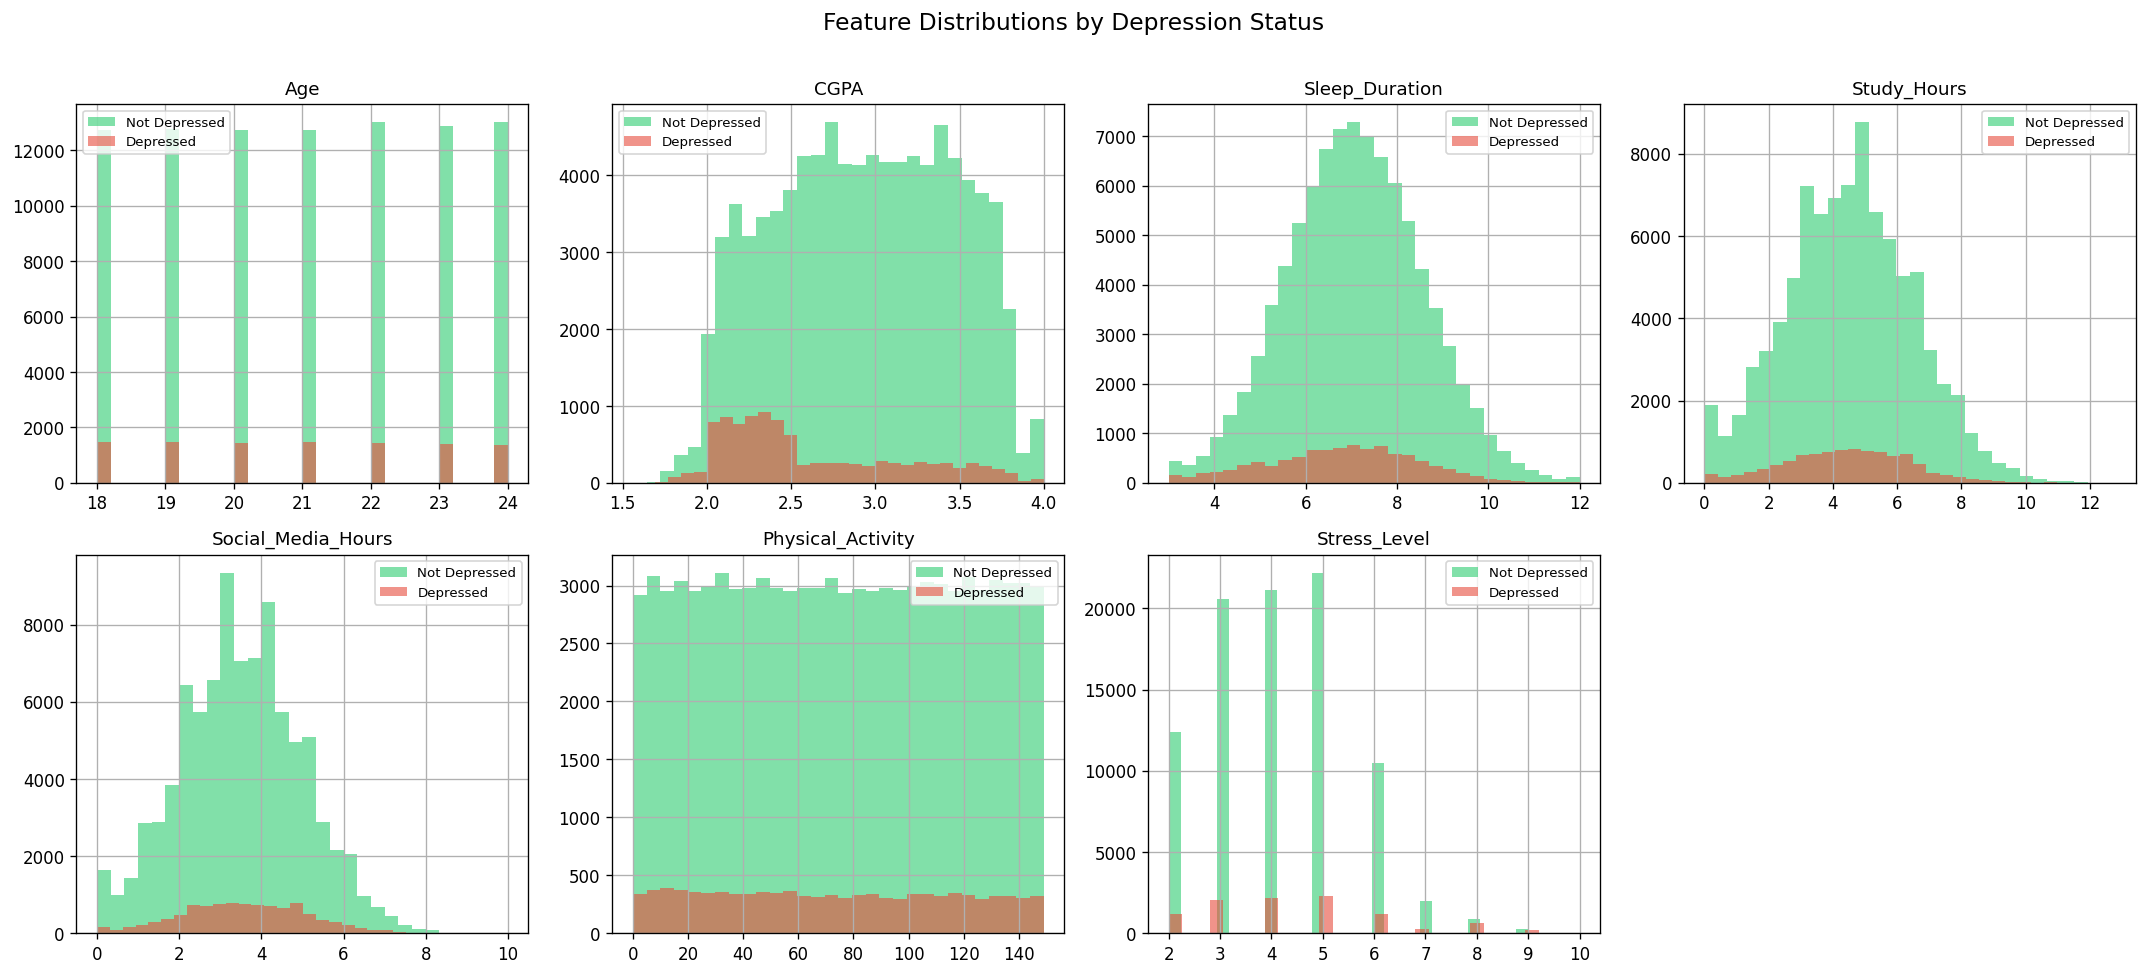

In [4]:
num_cols = ['Age','CGPA','Sleep_Duration','Study_Hours',
            'Social_Media_Hours','Physical_Activity','Stress_Level']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for dep_val, color, label in [(0,'#2ecc71','Not Depressed'),(1,'#e74c3c','Depressed')]:
        df[df[TARGET]==dep_val][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                          color=color, label=label, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('Feature Distributions by Depression Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [5]:
# Drop identifier
df.drop(columns=['Student_ID'], inplace=True)

# Feature Engineering
df['low_cgpa']             = (df['CGPA'] < 2.5).astype(int)
df['low_sleep']            = (df['Sleep_Duration'] < 6).astype(int)
df['high_stress']          = (df['Stress_Level'] >= 7).astype(int)
df['low_cgpa_high_stress'] = ((df['CGPA'] < 2.5) & (df['Stress_Level'] >= 6)).astype(int)
df['cgpa_x_stress']        = df['CGPA'] * df['Stress_Level']
df['sleep_x_stress']       = df['Sleep_Duration'] * df['Stress_Level']
df['cgpa_per_stress']      = df['CGPA'] / (df['Stress_Level'] + 0.001)
df['sleep_per_stress']     = df['Sleep_Duration'] / (df['Stress_Level'] + 0.001)
df['activity_x_sleep']     = df['Physical_Activity'] * df['Sleep_Duration']
df['social_x_stress']      = df['Social_Media_Hours'] * df['Stress_Level']
df['cgpa_sq']              = df['CGPA'] ** 2
df['stress_sq']            = df['Stress_Level'] ** 2

# One-hot encode nominal features
df = pd.get_dummies(df, columns=['Gender', 'Department'], drop_first=False, dtype=int)
print(f'Final shape: {df.shape}')

Final shape: (100000, 27)


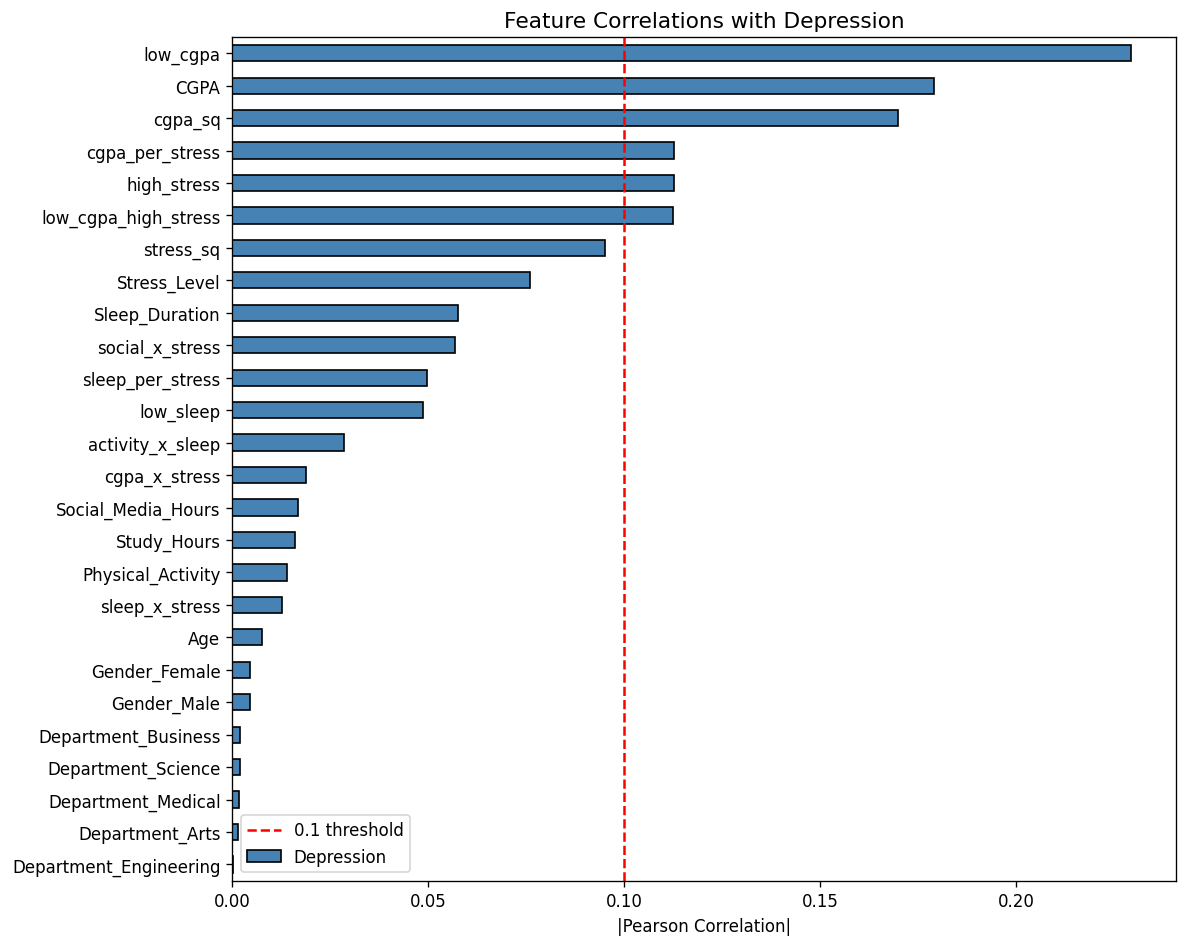

In [6]:
# Feature correlations with target
corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.invert_yaxis()
ax.axvline(0.1, color='red', linestyle='--', label='0.1 threshold')
ax.set_title('Feature Correlations with Depression', fontsize=13)
ax.set_xlabel('|Pearson Correlation|')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split (60/20/20 stratified)

In [7]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)

for name, X_, y_ in [('Train',X_train,y_train),('Validation',X_val,y_val),('Test',X_test,y_test)]:
    print(f'{name:12}: {len(X_):>6,} rows | Depressed: {y_.sum():,} ({100*y_.mean():.1f}%)')

Train       : 60,000 rows | Depressed: 6,038 (10.1%)
Validation  : 20,000 rows | Depressed: 2,012 (10.1%)
Test        : 20,000 rows | Depressed: 2,012 (10.1%)


## 6. Feature Scaling

> **Critical for SVM** — SVM is distance-based so unscaled features dominate the margin. Scaler is fit ONLY on train to prevent data leakage.

In [8]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Scaling applied')
print(f'Train mean (should be ~0): {X_train_sc.mean():.4f}')
print(f'Train std  (should be ~1): {X_train_sc.std():.4f}')

Scaling applied
Train mean (should be ~0): -0.0000
Train std  (should be ~1): 1.0000


## 7. Primary Model — LinearSVC + Calibration (Full Dataset)

`LinearSVC` is the correct SVM variant for 100k+ rows — it scales linearly.
`CalibratedClassifierCV` wraps it to produce probability scores needed for AUC-ROC.

In [9]:
param_grid = {
    'estimator__C':        [0.001, 0.01, 0.1, 1.0, 10.0],
    'estimator__max_iter': [2000],
    'estimator__loss':     ['hinge', 'squared_hinge'],
}

base_svm = LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)
calibrated_svm = CalibratedClassifierCV(base_svm, cv=3)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    calibrated_svm, param_grid, cv=cv,
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_sc, y_train)

print(f'Best CV AUC-ROC : {grid_search.best_score_:.4f}')
print(f'Best params     : {grid_search.best_params_}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV AUC-ROC : 0.6962
Best params     : {'estimator__C': 1.0, 'estimator__loss': 'hinge', 'estimator__max_iter': 2000}


## 8. Validate on Validation Set

In [10]:
best_svm    = grid_search.best_estimator_
y_val_pred  = best_svm.predict(X_val_sc)
y_val_proba = best_svm.predict_proba(X_val_sc)[:, 1]

print('=== Validation Set Performance ===')
print(f'Accuracy : {accuracy_score(y_val, y_val_pred):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_val, y_val_proba):.4f}')
print(f'F1 (w)   : {f1_score(y_val, y_val_pred, average="weighted"):.4f}')
print()
print(classification_report(y_val, y_val_pred, target_names=CLASS_LABELS))

=== Validation Set Performance ===
Accuracy : 0.8994
AUC-ROC  : 0.7073
F1 (w)   : 0.8518

               precision    recall  f1-score   support

Not Depressed       0.90      1.00      0.95     17988
    Depressed       0.00      0.00      0.00      2012

     accuracy                           0.90     20000
    macro avg       0.45      0.50      0.47     20000
 weighted avg       0.81      0.90      0.85     20000



## 9. Retrain Final Model on Train + Validation

In [11]:
X_trainval_sc  = np.vstack([X_train_sc, X_val_sc])
y_trainval_all = pd.concat([y_train, y_val])

best_C    = grid_search.best_params_['estimator__C']
best_loss = grid_search.best_params_['estimator__loss']

final_svm = CalibratedClassifierCV(
    LinearSVC(C=best_C, loss=best_loss, max_iter=2000,
              class_weight='balanced', random_state=RANDOM_STATE),
    cv=3
)
final_svm.fit(X_trainval_sc, y_trainval_all)
print('Final model trained on Train + Validation')

Final model trained on Train + Validation


## 10. Full Test Set Evaluation

In [12]:
y_test_pred  = final_svm.predict(X_test_sc)
y_test_proba = final_svm.predict_proba(X_test_sc)[:, 1]

acc      = accuracy_score(y_test, y_test_pred)
prec     = precision_score(y_test, y_test_pred)
rec      = recall_score(y_test, y_test_pred)
f1_w     = f1_score(y_test, y_test_pred, average='weighted')
f1_b     = f1_score(y_test, y_test_pred)
auc_roc  = roc_auc_score(y_test, y_test_proba)
avg_prec = average_precision_score(y_test, y_test_proba)

cm = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)

print('=' * 56)
print('           TEST SET - PERFORMANCE SUMMARY')
print('=' * 56)
print(f'  Accuracy                  : {acc:.4f}')
print(f'  Precision (Depressed)     : {prec:.4f}')
print(f'  Recall / Sensitivity      : {rec:.4f}')
print(f'  Specificity               : {specificity:.4f}')
print(f'  F1-Score (weighted)       : {f1_w:.4f}')
print(f'  F1-Score (Depressed class): {f1_b:.4f}')
print(f'  AUC-ROC                   : {auc_roc:.4f}')
print(f'  Avg Precision (PR curve)  : {avg_prec:.4f}')
print('=' * 56)
print()
print(f'  True  Positives (caught depressed)      : {TP:,}')
print(f'  False Positives (wrongly flagged)        : {FP:,}')
print(f'  True  Negatives (correct non-depressed) : {TN:,}')
print(f'  False Negatives (missed depressed)      : {FN:,}')

           TEST SET - PERFORMANCE SUMMARY
  Accuracy                  : 0.8952
  Precision (Depressed)     : 0.3398
  Recall / Sensitivity      : 0.0437
  Specificity               : 0.9905
  F1-Score (weighted)       : 0.8573
  F1-Score (Depressed class): 0.0775
  AUC-ROC                   : 0.6968
  Avg Precision (PR curve)  : 0.2120

  True  Positives (caught depressed)      : 88
  False Positives (wrongly flagged)        : 171
  True  Negatives (correct non-depressed) : 17,817
  False Negatives (missed depressed)      : 1,924


### 10.1 Full Classification Report

In [13]:
print(classification_report(y_test, y_test_pred, target_names=CLASS_LABELS))

               precision    recall  f1-score   support

Not Depressed       0.90      0.99      0.94     17988
    Depressed       0.34      0.04      0.08      2012

     accuracy                           0.90     20000
    macro avg       0.62      0.52      0.51     20000
 weighted avg       0.85      0.90      0.86     20000



### 10.2 Confusion Matrix

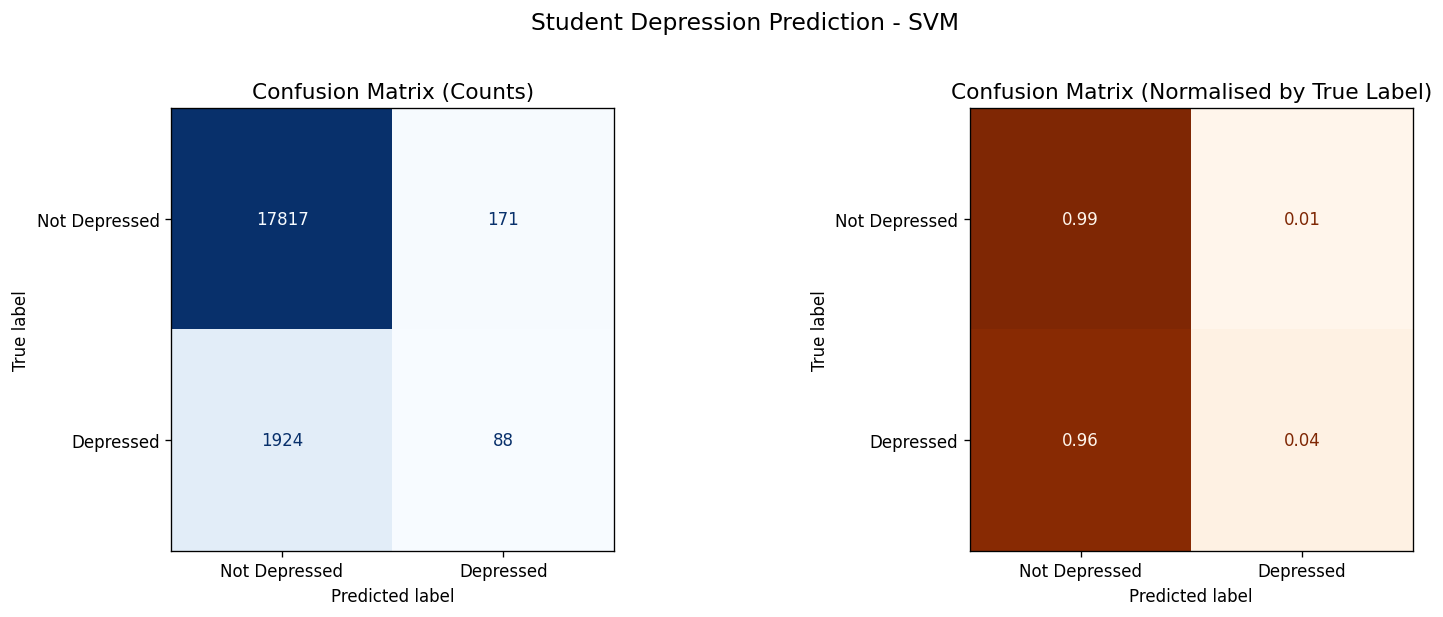

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS
    ).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13)

cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_LABELS
    ).plot(ax=axes[1], cmap='Oranges', colorbar=False, values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalised by True Label)', fontsize=13)

plt.suptitle('Student Depression Prediction - SVM', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 10.3 ROC and Precision-Recall Curves

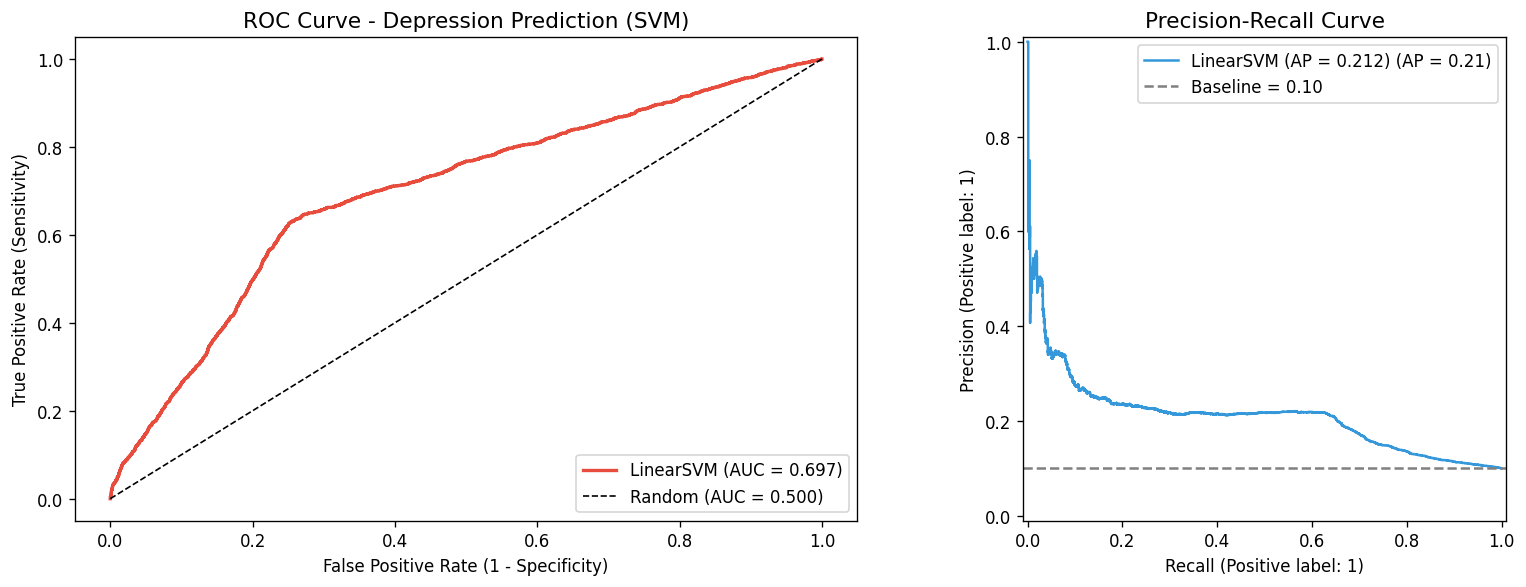

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'LinearSVM (AUC = {auc_roc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random (AUC = 0.500)')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve - Depression Prediction (SVM)', fontsize=13)
axes[0].legend(loc='lower right')

PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba, ax=axes[1],
    name=f'LinearSVM (AP = {avg_prec:.3f})', color='#3498db')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline = {y_test.mean():.2f}')
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend()
plt.tight_layout()
plt.show()

## 11. Bonus - RBF Kernel SVM (5k Stratified Sample)

RBF SVM cannot scale to 100k rows, but we demonstrate it on a 5k stratified sample.

In [16]:
X_sample, _, y_sample, _ = train_test_split(
    X_train_sc, y_train, test_size=0.9375,
    stratify=y_train, random_state=RANDOM_STATE)
print(f'RBF sample: {len(X_sample):,} rows | Depressed: {y_sample.sum():,} ({100*y_sample.mean():.1f}%)')

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale',
              class_weight='balanced', probability=True, random_state=RANDOM_STATE)
rbf_svm.fit(X_sample, y_sample)

y_rbf_pred  = rbf_svm.predict(X_test_sc)
y_rbf_proba = rbf_svm.predict_proba(X_test_sc)[:, 1]
cm_rbf      = confusion_matrix(y_test, y_rbf_pred)
TN_r, FP_r, FN_r, TP_r = cm_rbf.ravel()

print('\n=== RBF SVM (5k sample) ===')
print(f'Accuracy    : {accuracy_score(y_test, y_rbf_pred):.4f}')
print(f'Precision   : {precision_score(y_test, y_rbf_pred):.4f}')
print(f'Recall      : {recall_score(y_test, y_rbf_pred):.4f}')
print(f'Specificity : {TN_r/(TN_r+FP_r):.4f}')
print(f'F1 (w)      : {f1_score(y_test, y_rbf_pred, average="weighted"):.4f}')
print(f'AUC-ROC     : {roc_auc_score(y_test, y_rbf_proba):.4f}')

RBF sample: 3,750 rows | Depressed: 377 (10.1%)

=== RBF SVM (5k sample) ===
Accuracy    : 0.7197
Precision   : 0.1965
Recall      : 0.5785
Specificity : 0.7354
F1 (w)      : 0.7716
AUC-ROC     : 0.6780


## 12. Model Comparison — LinearSVM vs RBF SVM vs Decision Tree

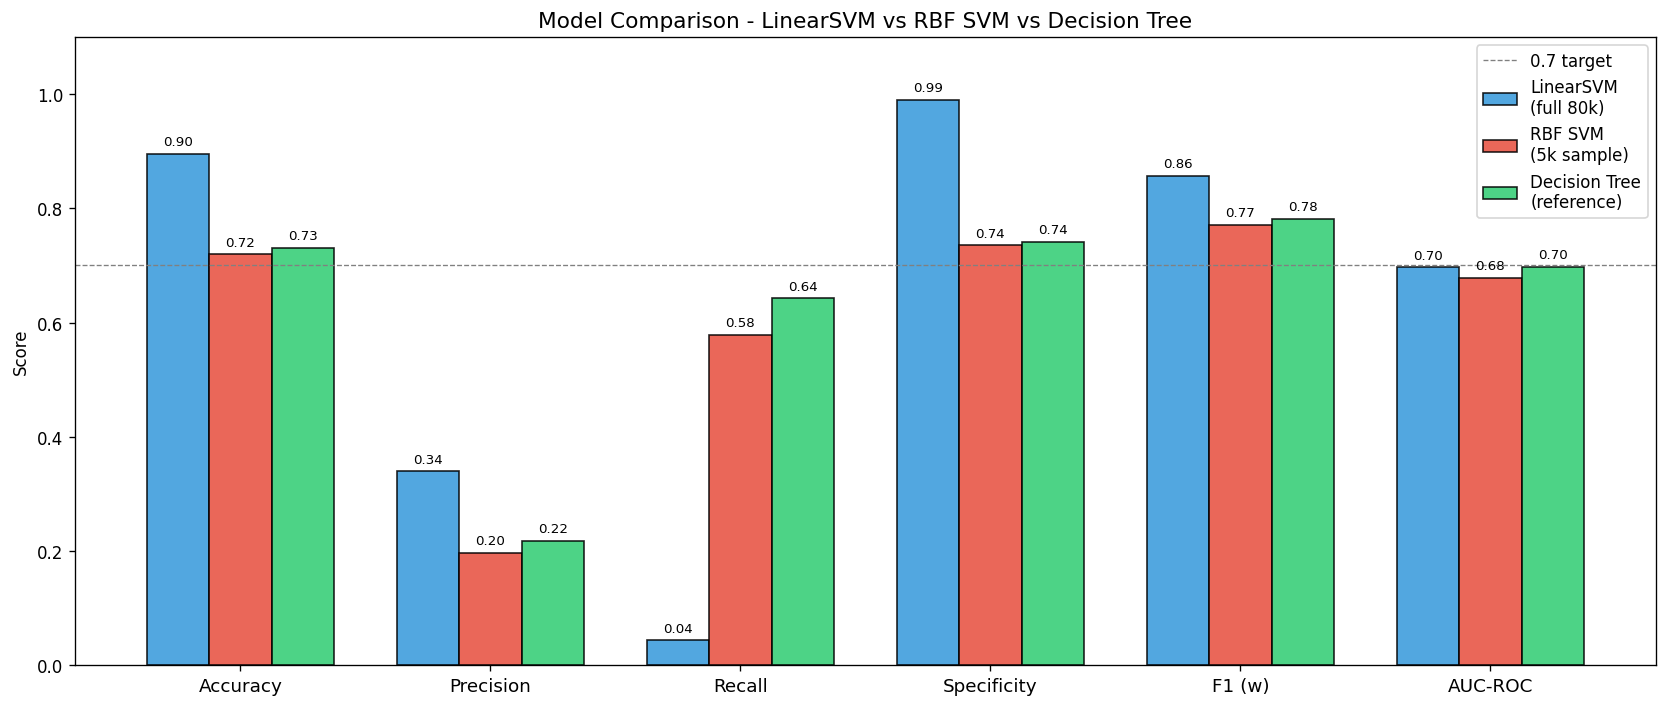

In [17]:
TN_r, FP_r, FN_r, TP_r = confusion_matrix(y_test, y_rbf_pred).ravel()

models = {
    'LinearSVM\n(full 80k)': {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'Specificity': specificity, 'F1 (w)': f1_w, 'AUC-ROC': auc_roc,
    },
    'RBF SVM\n(5k sample)': {
        'Accuracy':    accuracy_score(y_test, y_rbf_pred),
        'Precision':   precision_score(y_test, y_rbf_pred),
        'Recall':      recall_score(y_test, y_rbf_pred),
        'Specificity': TN_r / (TN_r + FP_r),
        'F1 (w)':      f1_score(y_test, y_rbf_pred, average='weighted'),
        'AUC-ROC':     roc_auc_score(y_test, y_rbf_proba),
    },
    'Decision Tree\n(reference)': {
        'Accuracy': 0.7312, 'Precision': 0.2173, 'Recall': 0.6426,
        'Specificity': 0.7412, 'F1 (w)': 0.7812, 'AUC-ROC': 0.6979,
    },
}

metrics_list = ['Accuracy','Precision','Recall','Specificity','F1 (w)','AUC-ROC']
x = np.arange(len(metrics_list))
width = 0.25
colors_m = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, scores) in enumerate(models.items()):
    vals = [scores[m] for m in metrics_list]
    bars = ax.bar(x + i*width, vals, width, label=model_name,
                  color=colors_m[i], edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, label='0.7 target')
ax.set_ylabel('Score')
ax.set_title('Model Comparison - LinearSVM vs RBF SVM vs Decision Tree', fontsize=13)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 13. Summary Dashboard

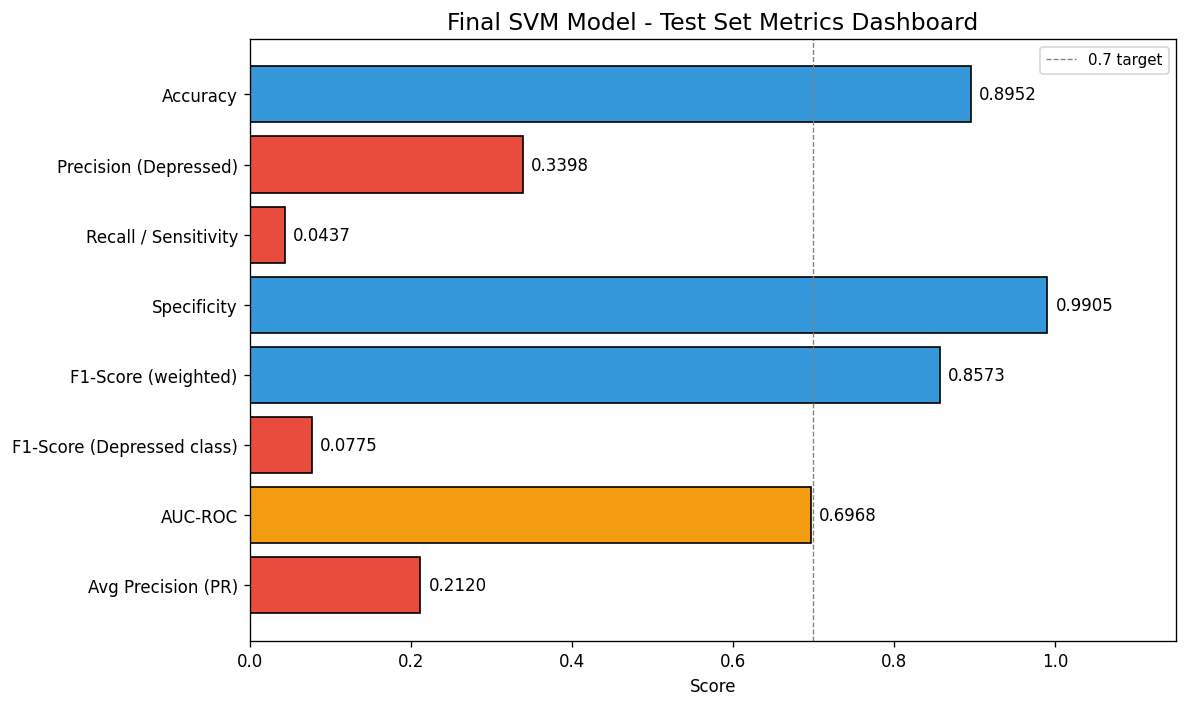

Note: Lower Precision/F1 (Depressed class) is driven by the 90/10 class imbalance.
AUC-ROC and Specificity are the most reliable indicators for imbalanced binary classification.


In [18]:
final_metrics = {
    'Accuracy':                   acc,
    'Precision (Depressed)':      prec,
    'Recall / Sensitivity':       rec,
    'Specificity':                specificity,
    'F1-Score (weighted)':        f1_w,
    'F1-Score (Depressed class)': f1_b,
    'AUC-ROC':                    auc_roc,
    'Avg Precision (PR)':         avg_prec,
}

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#3498db' if v >= 0.7 else '#f39c12' if v >= 0.5 else '#e74c3c'
              for v in final_metrics.values()]
bars = ax.barh(list(final_metrics.keys()), list(final_metrics.values()),
               color=bar_colors, edgecolor='black')
ax.set_xlim(0, 1.15)
ax.set_xlabel('Score')
ax.set_title('Final SVM Model - Test Set Metrics Dashboard', fontsize=14)
for bar, val in zip(bars, final_metrics.values()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.invert_yaxis()
ax.axvline(0.7, color='gray', linestyle='--', linewidth=0.8, label='0.7 target')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Note: Lower Precision/F1 (Depressed class) is driven by the 90/10 class imbalance.')
print('AUC-ROC and Specificity are the most reliable indicators for imbalanced binary classification.')